In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/Preprocessing/loans.csv")
data.head()

,client_id,loan_type,loan_amount,repaid,loan_id,loan_start,loan_end,rate
0,46109,home,13672,0,10243,2002-04-16,2003-12-20,2.15
1,46109,credit,9794,0,10984,2003-10-21,2005-07-17,1.25
2,46109,home,12734,1,10990,2006-02-01,2007-07-05,0.68
3,46109,cash,12518,1,10596,2010-12-08,2013-05-05,1.24
4,46109,credit,14049,1,11415,2010-07-07,2012-05-21,3.13


In [4]:
print(f"Shape of the data: {data.shape}")
print("==================================")
print(data.info)

Shape of the data: (443, 8)
<bound method DataFrame.info of      client_id loan_type  loan_amount  repaid  loan_id  loan_start  \
0        46109      home        13672       0    10243  2002-04-16   
1        46109    credit         9794       0    10984  2003-10-21   
2        46109      home        12734       1    10990  2006-02-01   
3        46109      cash        12518       1    10596  2010-12-08   
4        46109    credit        14049       1    11415  2010-07-07   
..         ...       ...          ...     ...      ...         ...   
438      26945     other        12963       0    10330  2001-11-26   
439      26945    credit         1728       1    10248  2004-01-27   
440      26945     other         9329       0    10154  2001-12-17   
441      26945      home         4197       0    10333  2003-10-16   
442      26945      home         3643       0    11434  2010-03-24   

       loan_end  rate  
0    2003-12-20  2.15  
1    2005-07-17  1.25  
2    2007-07-05  0.68  
3  

In [6]:
data.dtypes

,0
client_id,int64
loan_type,object
loan_amount,int64
repaid,int64
loan_id,int64
loan_start,object
loan_end,object
rate,float64


In [7]:
data["loan_id"] = data['loan_id'].astype("object")
data["repaid"] = data["repaid"].astype("category")

In [9]:
data['loan_start'] = pd.to_datetime(data['loan_start'], format="%Y-%m-%d")
data['loan_end'] = pd.to_datetime(data['loan_end'], format="%Y-%m-%d")

In [12]:
data.dtypes

,0
client_id,int64
loan_type,object
loan_amount,int64
repaid,category
loan_id,object
loan_start,datetime64[ns]
loan_end,datetime64[ns]
rate,float64


In [13]:
data.describe()

,client_id,loan_amount,loan_start,loan_end,rate
count,443.000000,443.000000,443,443,443.000000
mean,38911.060948,7982.311512,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536,3.217156
min,25707.000000,559.000000,2000-01-26 00:00:00,2001-08-02 00:00:00,0.010000
25%,32885.000000,4232.500000,2003-10-19 00:00:00,2005-09-12 12:00:00,1.220000
50%,39505.000000,8320.000000,2007-03-10 00:00:00,2009-03-19 00:00:00,2.780000
75%,46109.000000,11739.000000,2011-07-31 00:00:00,2013-09-11 12:00:00,4.750000
max,49624.000000,14971.000000,2014-11-11 00:00:00,2017-05-07 00:00:00,12.620000
std,7768.681063,4172.891992,NaN,NaN,2.397168


In [16]:
data.describe(exclude="number")

,loan_type,repaid,loan_id,loan_start,loan_end
count,443,443.0,443.0,443,443
unique,4,2.0,443.0,NaN,NaN
top,home,1.0,11434.0,NaN,NaN
freq,121,237.0,1.0,NaN,NaN
mean,NaN,NaN,NaN,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536
min,NaN,NaN,NaN,2000-01-26 00:00:00,2001-08-02 00:00:00
25%,NaN,NaN,NaN,2003-10-19 00:00:00,2005-09-12 12:00:00
50%,NaN,NaN,NaN,2007-03-10 00:00:00,2009-03-19 00:00:00
75%,NaN,NaN,NaN,2011-07-31 00:00:00,2013-09-11 12:00:00
max,NaN,NaN,NaN,2014-11-11 00:00:00,2017-05-07 00:00:00


In [20]:
data.index = data["loan_id"]
data.drop("loan_id", axis=1, inplace=True)
data.head()

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate
loan_id,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13


In [22]:
data.sort_index()

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate
loan_id,,,,,,,
10009,25707,other,2477,1,2009-05-25,2011-02-17,1.82
10017,35214,credit,7567,0,2004-02-11,2005-07-02,4.66
10024,49068,cash,4675,1,2005-03-29,2007-09-26,2.77
10032,38537,other,14342,1,2002-01-02,2003-10-14,1.29
10038,46180,cash,2628,1,2000-06-18,2002-04-06,3.14
...,...,...,...,...,...,...,...
11980,39505,cash,1918,0,2005-05-23,2007-01-15,3.05
11987,25707,other,12048,0,2010-10-20,2013-02-04,0.33
11988,26326,home,3597,1,2001-04-14,2003-03-06,2.74


In [24]:
data.isnull().sum()

,0
client_id,0
loan_type,0
loan_amount,0
repaid,0
loan_start,0
loan_end,0
rate,0


In [25]:
data.describe()

,client_id,loan_amount,loan_start,loan_end,rate
count,443.000000,443.000000,443,443,443.000000
mean,38911.060948,7982.311512,2007-08-02 12:56:53.092550912,2009-08-23 11:35:37.246049536,3.217156
min,25707.000000,559.000000,2000-01-26 00:00:00,2001-08-02 00:00:00,0.010000
25%,32885.000000,4232.500000,2003-10-19 00:00:00,2005-09-12 12:00:00,1.220000
50%,39505.000000,8320.000000,2007-03-10 00:00:00,2009-03-19 00:00:00,2.780000
75%,46109.000000,11739.000000,2011-07-31 00:00:00,2013-09-11 12:00:00,4.750000
max,49624.000000,14971.000000,2014-11-11 00:00:00,2017-05-07 00:00:00,12.620000
std,7768.681063,4172.891992,NaN,NaN,2.397168


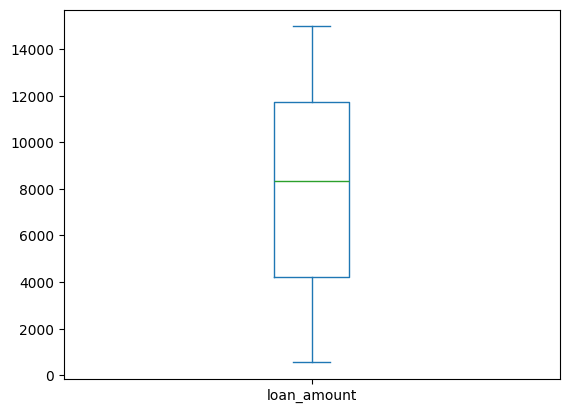

In [28]:
data["loan_amount"].plot(kind="box")
plt.show()

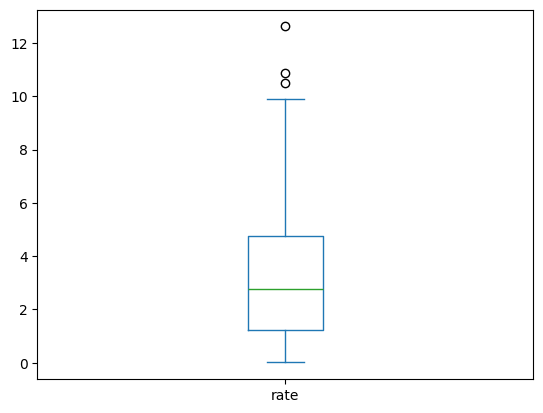

In [29]:
data["rate"].plot(kind="box")
plt.show()

In [32]:
data["Sqrt_rate"] = data['rate']**0.5
data["Log_rate"] = data['rate'].apply(np.log)

In [33]:
data

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate,Sqrt_rate,Log_rate
loan_id,,,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15,1.466288,0.765468
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25,1.118034,0.223144
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68,0.824621,-0.385662
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24,1.113553,0.215111
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13,1.769181,1.141033
...,...,...,...,...,...,...,...,...,...
10330,26945,other,12963,0,2001-11-26,2004-06-11,2.46,1.568439,0.900161
10248,26945,credit,1728,1,2004-01-27,2005-06-21,5.27,2.295648,1.662030
10154,26945,other,9329,0,2001-12-17,2004-07-22,5.65,2.376973,1.731656


In [37]:
print(f"Skewness of rate: {data['rate'].skew()}")
print(f"Skewness of sqrt_rate: {data['Sqrt_rate'].skew()}")
print(f"Skewness of log_rate: {data['Log_rate'].skew()}")
print(" ")
print("+++++++++++++++++++++++++++++++++++++++++++++++++")
print(" ")
print(f"Kurtosis of rate: {data['rate'].kurtosis()}")
print(f"Kurtosis of sqrt_rate: {data['Sqrt_rate'].kurtosis()}")
print(f"Kurtosis of log_rate: {data['Log_rate'].kurtosis()}")


Skewness of rate: 0.884204614329943
Skewness of sqrt_rate: 0.04964154055528862
Skewness of log_rate: -1.5943217626331552
 
+++++++++++++++++++++++++++++++++++++++++++++++++
 
Kurtosis of rate: 0.42437165143736433
Kurtosis of sqrt_rate: -0.6318437642052039
Kurtosis of log_rate: 4.157026150198228


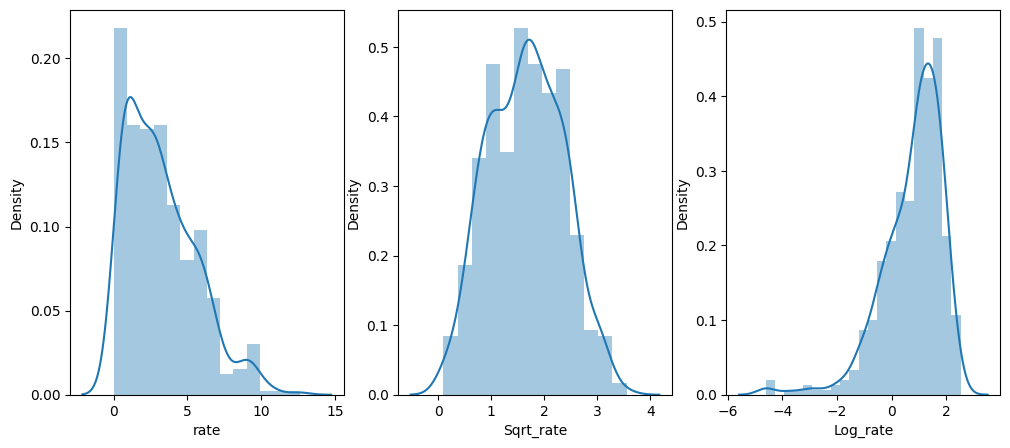

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.distplot(data["rate"], ax=axes[0])
sns.distplot(data["Sqrt_rate"], ax=axes[1])
sns.distplot(data["Log_rate"], ax=axes[2])

plt.show()

In [39]:
import scipy.stats as stats

In [40]:
data['Zscore'] = stats.zscore(data['rate'])
data.head()

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate,Sqrt_rate,Log_rate,Zscore
loan_id,,,,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15,1.466288,0.765468,-0.445677
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25,1.118034,0.223144,-0.821544
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68,0.824621,-0.385662,-1.059594
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24,1.113553,0.215111,-0.825721
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13,1.769181,1.141033,-0.036399


In [43]:
reduce_data = data[(data['Zscore']<= 3)&(data['Zscore']>= -3)]
reduce_data

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate,Sqrt_rate,Log_rate,Zscore
loan_id,,,,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15,1.466288,0.765468,-0.445677
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25,1.118034,0.223144,-0.821544
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68,0.824621,-0.385662,-1.059594
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24,1.113553,0.215111,-0.825721
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13,1.769181,1.141033,-0.036399
...,...,...,...,...,...,...,...,...,...,...
10330,26945,other,12963,0,2001-11-26,2004-06-11,2.46,1.568439,0.900161,-0.316211
10248,26945,credit,1728,1,2004-01-27,2005-06-21,5.27,2.295648,1.662030,0.857331
10154,26945,other,9329,0,2001-12-17,2004-07-22,5.65,2.376973,1.731656,1.016030


In [44]:
reduce_data2 = reduce_data.copy()

In [45]:
print(f"Shape of the original data: {data.shape}")
print(f"Shape of the reduced data: {reduce_data.shape}")

Shape of the original data: (443, 10)
Shape of the reduced data: (440, 10)


In [48]:
Q1 = reduce_data["rate"].quantile(0.25)
Q2 = reduce_data["rate"].quantile(0.50)
Q3 = reduce_data["rate"].quantile(0.75)
IQR = Q3 - Q1

LC = Q1 - 1.5 * IQR
UC = Q3 + 1.5 * IQR

print(f"Lower Cutoff: {LC}")
print(f"Upper Cutoff: {UC}")


Lower Cutoff: -3.9762499999999994
Upper Cutoff: 9.87375


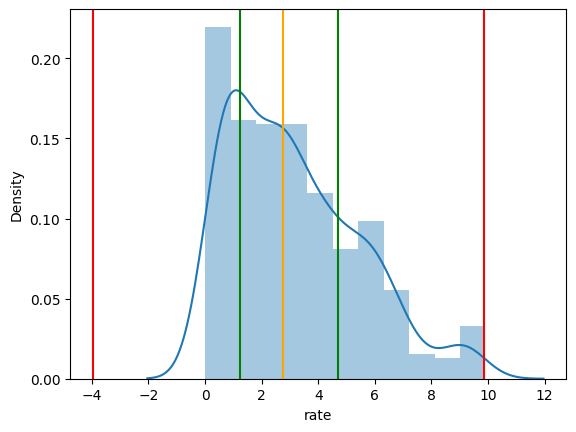

In [49]:
sns.distplot(reduce_data["rate"])
plt.axvline(LC, color="red")
plt.axvline(UC, color="red")
plt.axvline(Q1, color="green")
plt.axvline(Q2, color="orange")
plt.axvline(Q3, color="green")

plt.show()
#

In [54]:
reduce_data2 = reduce_data[(reduce_data["rate"] > LC) & (reduce_data["rate"] < UC)]
reduce_data2

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate,Sqrt_rate,Log_rate,Zscore
loan_id,,,,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15,1.466288,0.765468,-0.445677
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25,1.118034,0.223144,-0.821544
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68,0.824621,-0.385662,-1.059594
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24,1.113553,0.215111,-0.825721
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13,1.769181,1.141033,-0.036399
...,...,...,...,...,...,...,...,...,...,...
10330,26945,other,12963,0,2001-11-26,2004-06-11,2.46,1.568439,0.900161,-0.316211
10248,26945,credit,1728,1,2004-01-27,2005-06-21,5.27,2.295648,1.662030,0.857331
10154,26945,other,9329,0,2001-12-17,2004-07-22,5.65,2.376973,1.731656,1.016030


In [55]:
print(f"Shape of the original data: {data.shape}")
print(f"Shape of the reduced data: {reduce_data.shape}")
print(f"Shape of the reduced data2: {reduce_data2.shape}")

Shape of the original data: (443, 10)
Shape of the reduced data: (440, 10)
Shape of the reduced data2: (439, 10)


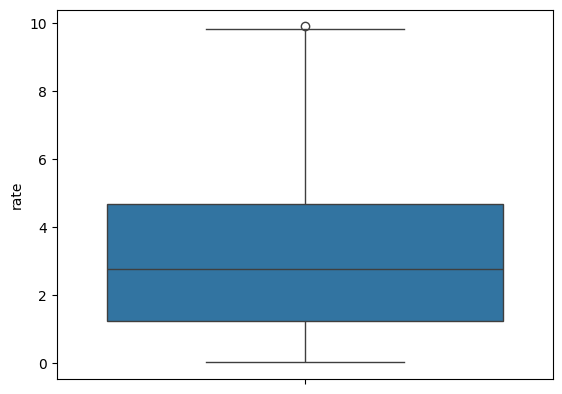

In [59]:
sns.boxplot(reduce_data["rate"])
plt.show()

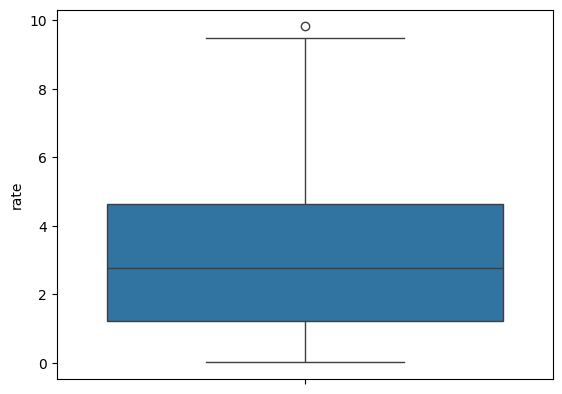

In [57]:
sns.boxplot(reduce_data2["rate"])
plt.show()

In [64]:
stdU = 3 * reduce_data["rate"].std()
reduce_data3 = reduce_data[(reduce_data["rate"] < stdU) & (reduce_data["rate"] > -stdU)]
reduce_data3

,client_id,loan_type,loan_amount,repaid,loan_start,loan_end,rate,Sqrt_rate,Log_rate,Zscore
loan_id,,,,,,,,,,
10243,46109,home,13672,0,2002-04-16,2003-12-20,2.15,1.466288,0.765468,-0.445677
10984,46109,credit,9794,0,2003-10-21,2005-07-17,1.25,1.118034,0.223144,-0.821544
10990,46109,home,12734,1,2006-02-01,2007-07-05,0.68,0.824621,-0.385662,-1.059594
10596,46109,cash,12518,1,2010-12-08,2013-05-05,1.24,1.113553,0.215111,-0.825721
11415,46109,credit,14049,1,2010-07-07,2012-05-21,3.13,1.769181,1.141033,-0.036399
...,...,...,...,...,...,...,...,...,...,...
10330,26945,other,12963,0,2001-11-26,2004-06-11,2.46,1.568439,0.900161,-0.316211
10248,26945,credit,1728,1,2004-01-27,2005-06-21,5.27,2.295648,1.662030,0.857331
10154,26945,other,9329,0,2001-12-17,2004-07-22,5.65,2.376973,1.731656,1.016030


In [65]:
print(f"Skewness of data: {data['rate'].skew()}")
print(f"Skewness of reduce_data: {reduce_data['rate'].skew()}")
print(f"Skewness of reduce_data2: {reduce_data2['rate'].skew()}")
print(f"Skewness of reduce_data3: {reduce_data3['rate'].skew()}")
print(" ")
print("+++++++++++++++++++++++++++++++++++++++++++++++++")
print(" ")
print(f"Kurtosis of data: {data['rate'].kurtosis()}")
print(f"Kurtosis of reduce_data: {reduce_data['rate'].kurtosis()}")
print(f"Kurtosis of reduce_data2: {reduce_data2['rate'].kurtosis()}")
print(f"Kurtosis of reduce_data3: {reduce_data3['rate'].kurtosis()}")



Skewness of data: 0.884204614329943
Skewness of reduce_data: 0.7594062707815686
Skewness of reduce_data2: 0.7427101742731893
Skewness of reduce_data3: 0.4162117709284904
 
+++++++++++++++++++++++++++++++++++++++++++++++++
 
Kurtosis of data: 0.42437165143736433
Kurtosis of reduce_data: -0.05964248048746912
Kurtosis of reduce_data2: -0.10284962185127
Kurtosis of reduce_data3: -0.9354294837952164


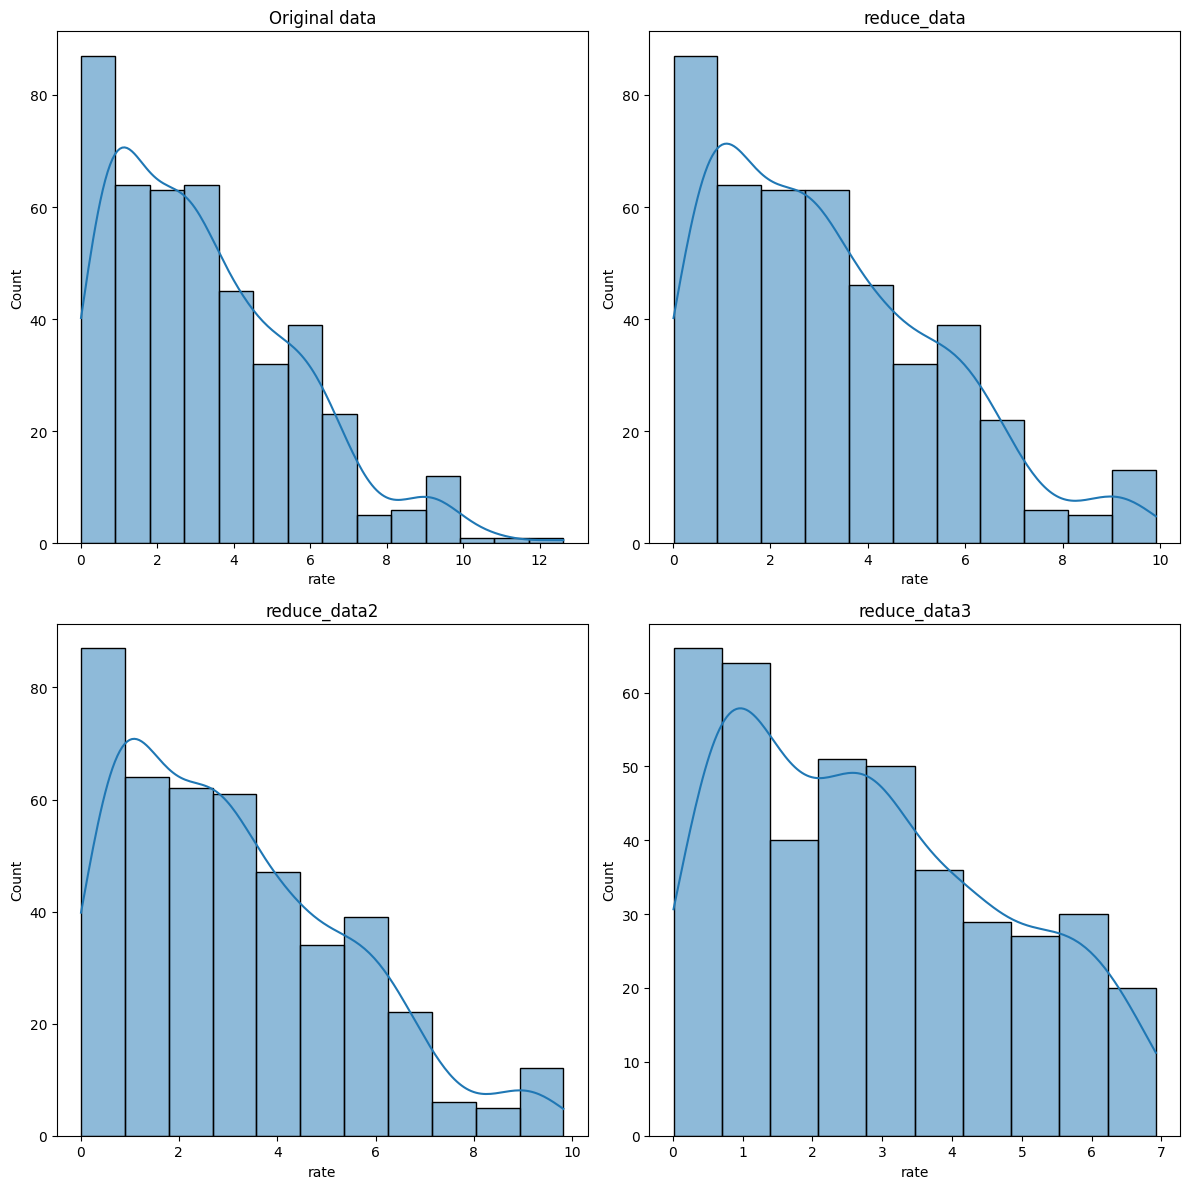

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

sns.histplot(data["rate"], ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Original data")

sns.histplot(reduce_data["rate"], ax=axes[0, 1], kde=True)
axes[0, 1].set_title("reduce_data")

sns.histplot(reduce_data2["rate"], ax=axes[1, 0], kde=True)
axes[1, 0].set_title("reduce_data2")

sns.histplot(reduce_data3["rate"], ax=axes[1, 1], kde=True)
axes[1, 1].set_title("reduce_data3")

plt.tight_layout()
plt.show()
